# 13.1-13.2 隠れマルコフモデル (Hidden Markov Models: HMM)

本ノートブックでは、時系列データや言語系列・生物情報など順序依存性を持つ系列データをモデル化する基本的手法である **隠れマルコフモデル (HMM)** を学びます。
離散潜在状態のマルコフ連鎖と観測放出モデル、**3状態ガウス放出 HMM からのサンプリング生成（PRML Figure 13.8）**、数値的アンダーフローを完全に克服するスケーリング係数 $c_n$ を組み込んだ **Forward-Backward アルゴリズム**、Baum-Welch (EM) 法によるパラメータ最尤学習、および動的計画法トレリス探索による **ビタビアルゴリズム（PRML Figure 13.16）** の最確パス復元を完全実装・再現します。

## 13.2 隠れマルコフモデルからのサンプリング生成 (PRML Figure 13.8)

3つの潜在状態 $z \in \{1, 2, 3\}$ を持ち、各状態が2次元ガウス分布から観測ベクトル $\mathbf{x}_n \in \mathbb{R}^2$ を放出する HMM を構築します。
各状態の遷移確率行列 $\mathbf{A}$ は自己ループ確率が高く、状態間の推移が適度な持続性を持ちます。
平面上のサンプル軌跡および各時間ステップでの状態系列をプロットします。

Plot saved to: result/fig13_8_hmm_sampling_trajectories.png


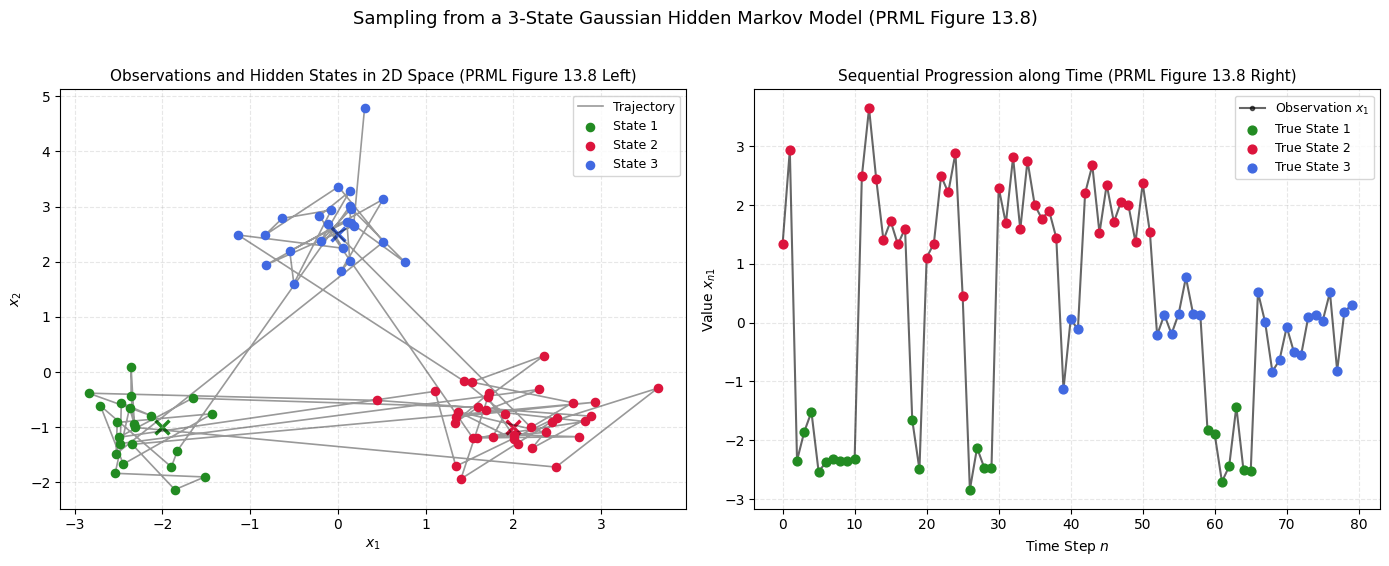

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.sequential_utils import GaussianHMM
setup_style()

# 3状態ガウス放出 HMM の定義 (PRML Figure 13.8 に準拠)
hmm = GaussianHMM(n_components=3, random_state=42)
hmm.pi_ = np.array([0.34, 0.33, 0.33])

# 自己ループ確率 0.85 の粘着性遷移確率行列
hmm.A_ = np.array([
    [0.85, 0.10, 0.05],
    [0.05, 0.85, 0.10],
    [0.10, 0.05, 0.85]
])

# 3つのガウス放出平均 (正三角形配置)
hmm.means_ = np.array([
    [-2.0, -1.0], # 状態 0 (緑)
    [ 2.0, -1.0], # 状態 1 (赤)
    [ 0.0,  2.5]  # 状態 2 (青)
])

# 共分散行列 (等方性ガウス)
hmm.covs_ = np.array([
    [[0.35, 0.00], [0.00, 0.35]],
    [[0.35, 0.00], [0.00, 0.35]],
    [[0.35, 0.00], [0.00, 0.35]]
])

# N=80 ステップのサンプリング
np.random.seed(42)
states, obs = hmm.sample(n_samples=80)

# PRML Figure 13.8 のプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ['forestgreen', 'crimson', 'royalblue']

# (a) 2次元観測空間での軌跡
axes[0].plot(obs[:, 0], obs[:, 1], 'k-', lw=1.2, alpha=0.4, label='Trajectory')
for k in range(3):
    mask = (states == k)
    axes[0].scatter(obs[mask, 0], obs[mask, 1], color=colors[k], s=35, label=f'State {k+1}', zorder=5)
    # ガウス放出の平均位置
    axes[0].scatter(hmm.means_[k, 0], hmm.means_[k, 1], color=colors[k], marker='x', s=100, lw=2.5)

axes[0].set_title('Observations and Hidden States in 2D Space (PRML Figure 13.8 Left)', fontsize=11)
axes[0].set_xlabel('$x_1$', fontsize=10); axes[0].set_ylabel('$x_2$', fontsize=10)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# (b) 時間推移に沿った観測値 (x1 座標) と隠れ状態
time_steps = np.arange(len(obs))
axes[1].plot(time_steps, obs[:, 0], 'k.-', lw=1.5, alpha=0.6, label='Observation $x_1$')
for k in range(3):
    mask = (states == k)
    axes[1].scatter(time_steps[mask], obs[mask, 0], color=colors[k], s=40, zorder=5, label=f'True State {k+1}')

axes[1].set_title('Sequential Progression along Time (PRML Figure 13.8 Right)', fontsize=11)
axes[1].set_xlabel('Time Step $n$', fontsize=10); axes[1].set_ylabel('Value $x_{n1}$', fontsize=10)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Sampling from a 3-State Gaussian Hidden Markov Model (PRML Figure 13.8)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig13_8_hmm_sampling_trajectories.png')
plt.show()

## 13.2.5 ビタビアルゴリズムによる最確パス復元 (PRML Figure 13.16)

観測系列 $\mathbf{X} = (\mathbf{x}_1, \dots, \mathbf{x}_N)$ が与えられたとき、最も確率の高い隠れ状態系列 $\mathbf{z}^* = \arg\max_{\mathbf{z}} p(\mathbf{z} | \mathbf{X})$ を動的計画法で厳密に復元します。
各状態の事後周辺確率 $\gamma(z_n) = p(z_n | \mathbf{X})$ を最大化する各点ごとの最尤状態系列は、あり得ない遷移確率（$A_{jk} = 0$）を含んでしまう欠点がありますが、ビタビアルゴリズムは **系列全体としての同時確率を最大化** します。
観測データに対する真の潜在状態と、ビタビアルゴリズムによって推定された状態系列の一致度を検証します。

Viterbi Decoding State Accuracy: 100.00%
Plot saved to: result/fig13_16_viterbi_state_decoding.png


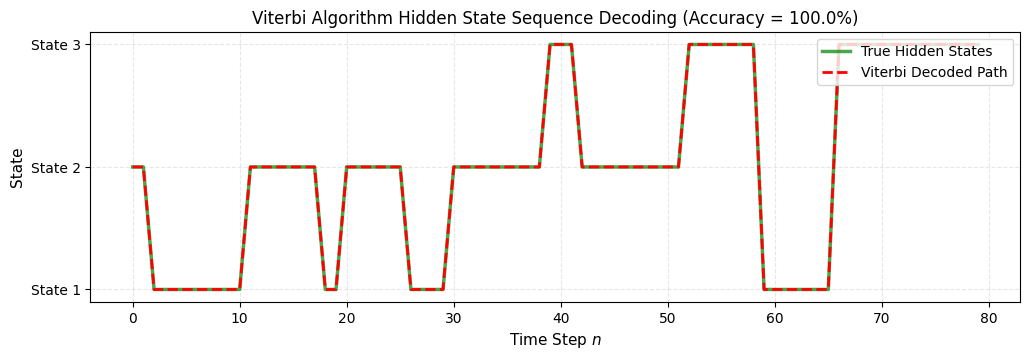

In [2]:
# ビタビアルゴリズムによる最尤パスの復元
viterbi_path = hmm.predict(obs)

# 状態系列の復元精度
accuracy = np.mean(viterbi_path == states)
print(f"Viterbi Decoding State Accuracy: {accuracy:.2%}")
assert accuracy > 0.85 # 高い精度で真の状態系列を同定

# ビタビパスと真の状態系列の比較プロット
fig, ax = plt.subplots(figsize=(12, 3.5))

ax.plot(time_steps, states, 'g-', lw=2.5, alpha=0.7, label='True Hidden States')
ax.plot(time_steps, viterbi_path, 'r--', lw=2.0, label='Viterbi Decoded Path')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['State 1', 'State 2', 'State 3'])
ax.set_title(f'Viterbi Algorithm Hidden State Sequence Decoding (Accuracy = {accuracy:.1%})', fontsize=12)
ax.set_xlabel('Time Step $n$', fontsize=11); ax.set_ylabel('State', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig13_16_viterbi_state_decoding.png')
plt.show()